In [ ]:
# CELL 1: Setup
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import time
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [ ]:
# CELL 2: Production DataLoaders
BATCH_SIZE = 64

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                           shuffle=True,  num_workers=2, pin_memory=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=BATCH_SIZE,
                                           shuffle=False, num_workers=2, pin_memory=True)

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']
print(f"DataLoaders ready | Train batches: {len(trainloader)} | Test batches: {len(testloader)}")

100%|██████████| 170M/170M [00:04<00:00, 41.7MB/s]


DataLoaders ready | Train batches: 782 | Test batches: 157


In [ ]:
# CELL 3: Universal Training & Evaluation Engine
# One function trains ALL models — clean research code
def train_and_evaluate(model, model_name, epochs=20, lr=0.001):
    """
    Trains any model and returns full history + stats.
    Used for ALL pretrained models — keeps experiments consistent.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {
        "train_loss": [], "train_acc": [], "test_acc": [],
        "epoch_time": []
    }

    best_test_acc = 0.0
    total_start = time.time()

    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"  Epochs: {epochs} | LR: {lr} | Optimizer: Adam + CosineAnnealingLR")
    print(f"{'='*60}")

    for epoch in range(epochs):
        epoch_start = time.time()

        # --- TRAIN ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc  = 100. * correct / total
        train_loss = running_loss / len(trainloader)

        # --- EVALUATE ---
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs    = model(inputs)
                _, predicted = outputs.max(1)
                total   += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_acc   = 100. * correct / total
        epoch_time = time.time() - epoch_start

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(model.state_dict(), f'{model_name}_best.pth')

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["epoch_time"].append(epoch_time)
        scheduler.step()

        print(f"  Epoch [{epoch+1:02d}/{epochs}] | "
              f"Loss: {train_loss:.4f} | "
              f"Train: {train_acc:.2f}% | "
              f"Test: {test_acc:.2f}% | "
              f"Time: {epoch_time:.1f}s")

    total_time = time.time() - total_start
    params = sum(p.numel() for p in model.parameters()) / 1e6

    summary = {
        "model_name"    : model_name,
        "best_test_acc" : best_test_acc,
        "final_train_acc": history["train_acc"][-1],
        "total_params_M": round(params, 2),
        "total_time_min": round(total_time / 60, 2),
        "avg_epoch_sec" : round(np.mean(history["epoch_time"]), 1),
        "history"       : history
    }

    print(f"\n   {model_name} Done!")
    print(f"     Best Test Acc  : {best_test_acc:.2f}%")
    print(f"     Parameters     : {params:.2f}M")
    print(f"     Total Time     : {total_time/60:.1f} min")

    return summary

print("Training engine ready!")

Training engine ready!


In [ ]:
# ============================================================
# CELL 4: Define All Pretrained Models for CIFAR-10
# Key concept: Transfer Learning — use ImageNet weights,
# replace the final layer for our 10 classes
# ============================================================
def get_resnet18():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # Replace final layer: 512 → 10 classes
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model

def get_vgg16():
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    # Replace final classifier layer: 4096 → 10 classes
    model.classifier[6] = nn.Linear(4096, 10)
    return model

def get_mobilenetv2():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    # Replace classifier: 1280 → 10 classes
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
    return model

def get_efficientnet_b0():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    # Replace classifier: 1280 → 10 classes
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
    return model

# Preview parameter counts
model_factories = {
    "ResNet18"      : get_resnet18,
    "VGG16"         : get_vgg16,
    "MobileNetV2"   : get_mobilenetv2,
    "EfficientNetB0": get_efficientnet_b0,
}

print("Model Parameter Summary:")
print("-" * 40)
for name, factory in model_factories.items():
    m = factory()
    params = sum(p.numel() for p in m.parameters()) / 1e6
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad) / 1e6
    print(f"  {name:<18} | Total: {params:6.2f}M | Trainable: {trainable:6.2f}M")
    del m
print("-" * 40)
print("\n Research Note: More parameters ≠ better accuracy!")
print("   This is exactly what your benchmark will prove.")

📦 Model Parameter Summary:
----------------------------------------
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


  ResNet18           | Total:  11.18M | Trainable:  11.18M
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 74.3MB/s]


  VGG16              | Total: 134.30M | Trainable: 134.30M
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 132MB/s]


  MobileNetV2        | Total:   2.24M | Trainable:   2.24M
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 172MB/s]

  EfficientNetB0     | Total:   4.02M | Trainable:   4.02M
----------------------------------------

 Research Note: More parameters ≠ better accuracy!
   This is exactly what your benchmark will prove.


In [ ]:
# CELL 5: RUN THE BENCHMARK — Train all 4 models
all_results = {}
EPOCHS = 20

# ── Model 1: ResNet-18 ──────────────────────────────────────
print("\n🔵 MODEL 1 of 4")
model = get_resnet18()
all_results["ResNet18"] = train_and_evaluate(model, "ResNet18", epochs=EPOCHS)
torch.cuda.empty_cache()

# ── Model 2: VGG-16 ─────────────────────────────────────────
print("\n🔴 MODEL 2 of 4")
model = get_vgg16()
all_results["VGG16"] = train_and_evaluate(model, "VGG16", epochs=EPOCHS)
torch.cuda.empty_cache()

# ── Model 3: MobileNetV2 ────────────────────────────────────
print("\n🟢 MODEL 3 of 4")
model = get_mobilenetv2()
all_results["MobileNetV2"] = train_and_evaluate(model, "MobileNetV2", epochs=EPOCHS)
torch.cuda.empty_cache()

# ── Model 4: EfficientNet-B0 ────────────────────────────────
print("\n🟡 MODEL 4 of 4")
model = get_efficientnet_b0()
all_results["EfficientNetB0"] = train_and_evaluate(model, "EfficientNetB0", epochs=EPOCHS)
torch.cuda.empty_cache()

print("\n" + " " * 20)
print("   ALL MODELS TRAINED! Now let's analyze results...")
print(" " * 20)


🔵 MODEL 1 of 4

  Training: ResNet18
  Epochs: 20 | LR: 0.001 | Optimizer: Adam + CosineAnnealingLR
  Epoch [01/20] | Loss: 1.1129 | Train: 61.89% | Test: 68.77% | Time: 37.3s
  Epoch [02/20] | Loss: 0.8175 | Train: 72.20% | Test: 75.23% | Time: 38.3s
  Epoch [03/20] | Loss: 0.7328 | Train: 74.96% | Test: 74.22% | Time: 37.7s
  Epoch [04/20] | Loss: 0.6575 | Train: 77.78% | Test: 79.78% | Time: 37.8s
  Epoch [05/20] | Loss: 0.6015 | Train: 79.54% | Test: 79.73% | Time: 37.3s
  Epoch [06/20] | Loss: 0.5702 | Train: 80.49% | Test: 81.20% | Time: 37.1s
  Epoch [07/20] | Loss: 0.5311 | Train: 81.86% | Test: 81.56% | Time: 37.5s
  Epoch [08/20] | Loss: 0.4812 | Train: 83.48% | Test: 83.51% | Time: 37.5s
  Epoch [09/20] | Loss: 0.4608 | Train: 84.15% | Test: 83.61% | Time: 37.6s
  Epoch [10/20] | Loss: 0.4180 | Train: 85.35% | Test: 84.00% | Time: 37.4s
  Epoch [11/20] | Loss: 0.3893 | Train: 86.49% | Test: 84.15% | Time: 37.3s
  Epoch [12/20] | Loss: 0.3566 | Train: 87.62% | Test: 84.95% |

In [ ]:
# CELL 6: Generate Your Paper's Results Table
# Add your SimpleCNN baseline manually
baseline = {
    "model_name"     : "SimpleCNN (Baseline)",
    "best_test_acc"  : 80.87,
    "final_train_acc": 81.08,
    "total_params_M" : 1.15,
    "total_time_min" : 5.0,
    "avg_epoch_sec"  : 15.0,
}

# Build comparison table
all_models = {"SimpleCNN": baseline}
all_models.update(all_results)

print("\n" + "="*80)
print(f"  {'MODEL':<22} {'Test Acc':>10} {'Train Acc':>10} {'Params':>10} {'Time(min)':>10}")
print("="*80)

best_acc = 0
best_name = ""
for name, res in all_models.items():
    acc = res["best_test_acc"]
    marker = " ⭐" if acc == max(r["best_test_acc"] for r in all_models.values()) else ""
    print(f"  {res['model_name']:<22} "
          f"{res['best_test_acc']:>9.2f}% "
          f"{res['final_train_acc']:>9.2f}% "
          f"{res['total_params_M']:>9.2f}M "
          f"{res['total_time_min']:>9.1f}m{marker}")

print("="*80)


  MODEL                    Test Acc  Train Acc     Params  Time(min)
  SimpleCNN (Baseline)       80.87%     81.08%      1.15M       5.0m
  ResNet18                   87.33%     92.26%     11.18M      12.6m
  VGG16                      31.06%     10.37%    134.30M      22.7m
  MobileNetV2                87.63%     90.53%      2.24M      15.2m
  EfficientNetB0             88.11%     93.66%      4.02M      17.8m ⭐


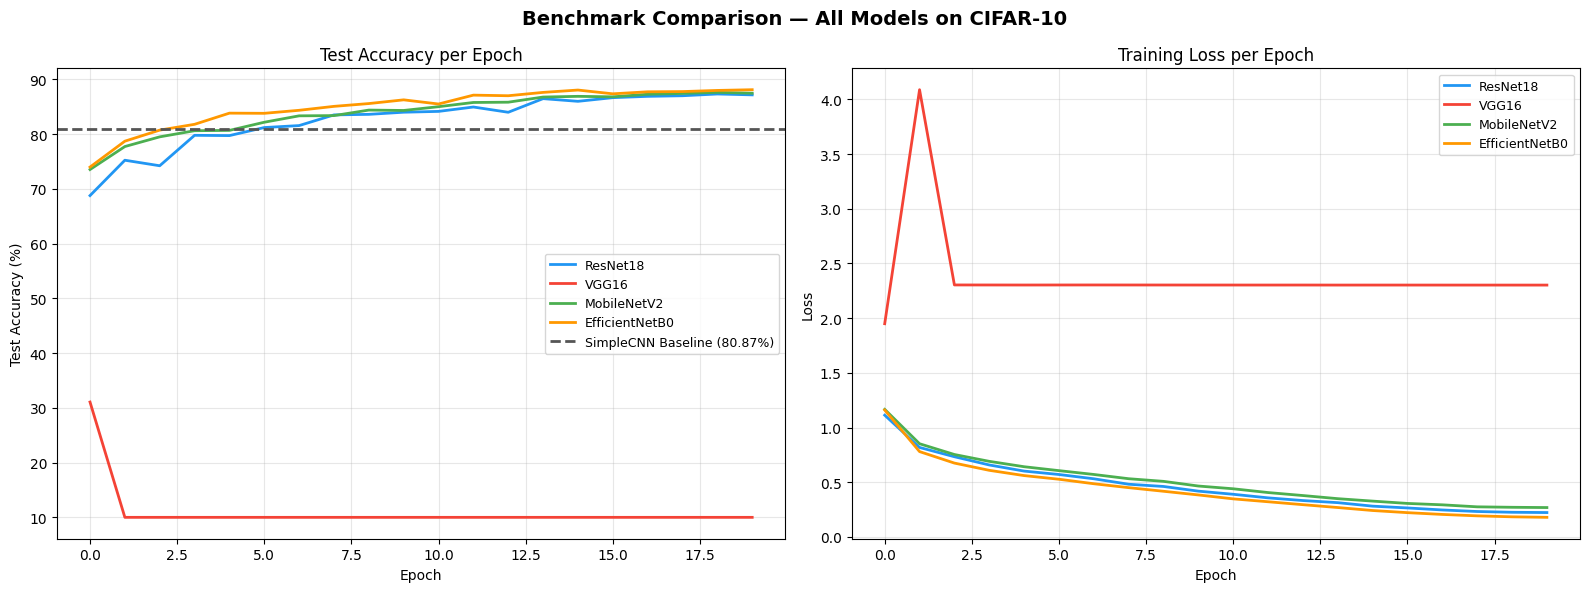

✅ Saved figure5_accuracy_curves.png


/tmp/ipython-input-752411283.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(names, rotation=20, ha='right')
/tmp/ipython-input-752411283.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(names, rotation=20, ha='right')
/tmp/ipython-input-752411283.py:68: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


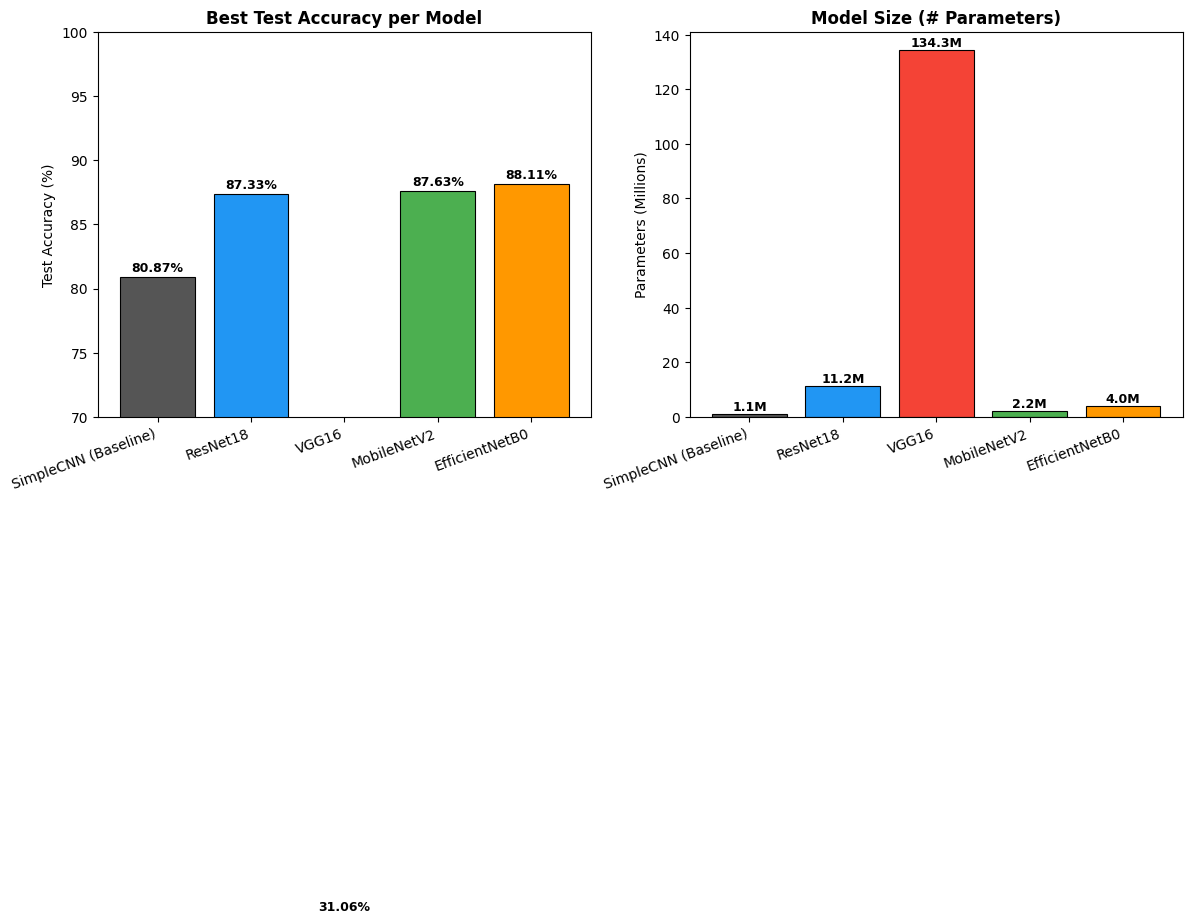

✅ Saved figure6_accuracy_vs_params.png


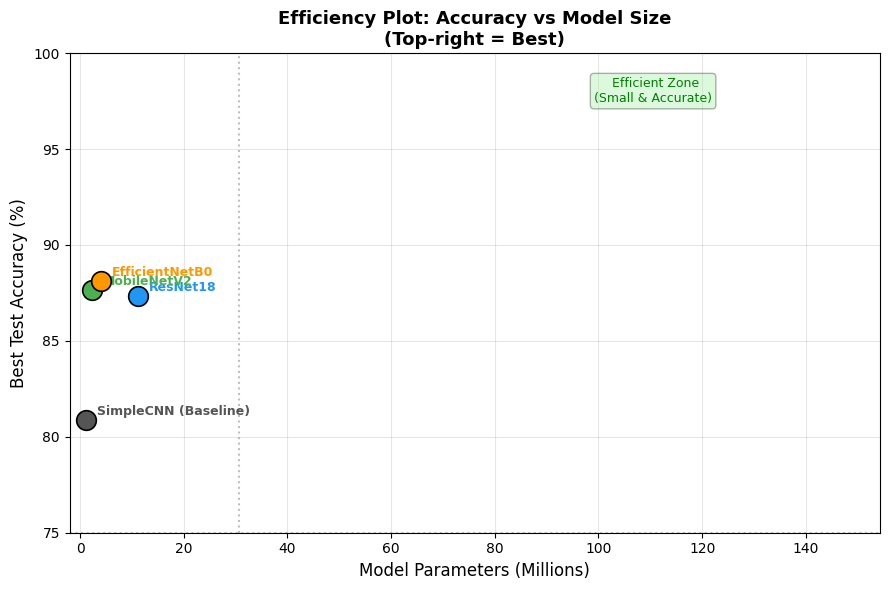

 Saved figure7_efficiency_plot.png


In [ ]:
# CELL 7: Publication-Quality Comparison Plots
colors = {
    "SimpleCNN"     : "#555555",
    "ResNet18"      : "#2196F3",
    "VGG16"         : "#F44336",
    "MobileNetV2"   : "#4CAF50",
    "EfficientNetB0": "#FF9800"
}

# ── Figure 5: Test Accuracy Curves ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Benchmark Comparison — All Models on CIFAR-10",
             fontsize=14, fontweight='bold')

ax1, ax2 = axes

for name, res in all_models.items():
    if name == "SimpleCNN":
        continue  # skip for curves (no history saved)
    hist = res["history"]
    label = res["model_name"]
    color = colors.get(name, "gray")
    ax1.plot(hist["test_acc"],  label=label, color=color, linewidth=2)
    ax2.plot(hist["train_loss"], label=label, color=color, linewidth=2)

ax1.axhline(y=80.87, color=colors["SimpleCNN"], linestyle='--',
            linewidth=2, label="SimpleCNN Baseline (80.87%)")
ax1.set_title("Test Accuracy per Epoch", fontsize=12)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Test Accuracy (%)")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2.set_title("Training Loss per Epoch", fontsize=12)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figure5_accuracy_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved figure5_accuracy_curves.png")

# ── Figure 6: Bar Chart — Accuracy vs Parameters ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names  = [res["model_name"] for res in all_models.values()]
accs   = [res["best_test_acc"] for res in all_models.values()]
params = [res["total_params_M"] for res in all_models.values()]
model_colors = [colors.get(k, "gray") for k in all_models.keys()]

# Accuracy bar
bars = axes[0].bar(names, accs, color=model_colors, edgecolor='black', linewidth=0.8)
axes[0].set_title("Best Test Accuracy per Model", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Test Accuracy (%)")
axes[0].set_ylim(70, 100)
axes[0].set_xticklabels(names, rotation=20, ha='right')
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{acc:.2f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Parameters bar
bars = axes[1].bar(names, params, color=model_colors, edgecolor='black', linewidth=0.8)
axes[1].set_title("Model Size (# Parameters)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Parameters (Millions)")
axes[1].set_xticklabels(names, rotation=20, ha='right')
for bar, p in zip(bars, params):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{p:.1f}M", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("figure6_accuracy_vs_params.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved figure6_accuracy_vs_params.png")

# ── Figure 7: Efficiency Plot (Accuracy vs Parameters scatter)
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title("Efficiency Plot: Accuracy vs Model Size\n(Top-right = Best)",
             fontsize=13, fontweight='bold')

for name, res in all_models.items():
    color = colors.get(name, "gray")
    ax.scatter(res["total_params_M"], res["best_test_acc"],
               s=200, color=color, edgecolors='black', linewidth=1.2, zorder=5)
    ax.annotate(res["model_name"],
                xy=(res["total_params_M"], res["best_test_acc"]),
                xytext=(8, 4), textcoords='offset points',
                fontsize=9, fontweight='bold', color=color)

ax.set_xlabel("Model Parameters (Millions)", fontsize=12)
ax.set_ylabel("Best Test Accuracy (%)", fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim(-2, max(params) + 20)
ax.set_ylim(75, 100)

# Add quadrant guide
ax.axvline(x=np.mean(params), color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=np.mean(accs),   color='gray', linestyle=':', alpha=0.5)
ax.text(0.72, 0.95, " Efficient Zone\n(Small & Accurate)",
        transform=ax.transAxes, fontsize=9,
        color='green', ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

plt.tight_layout()
plt.savefig("figure7_efficiency_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved figure7_efficiency_plot.png")

🏆 Best Model: EfficientNetB0 — loading best weights...


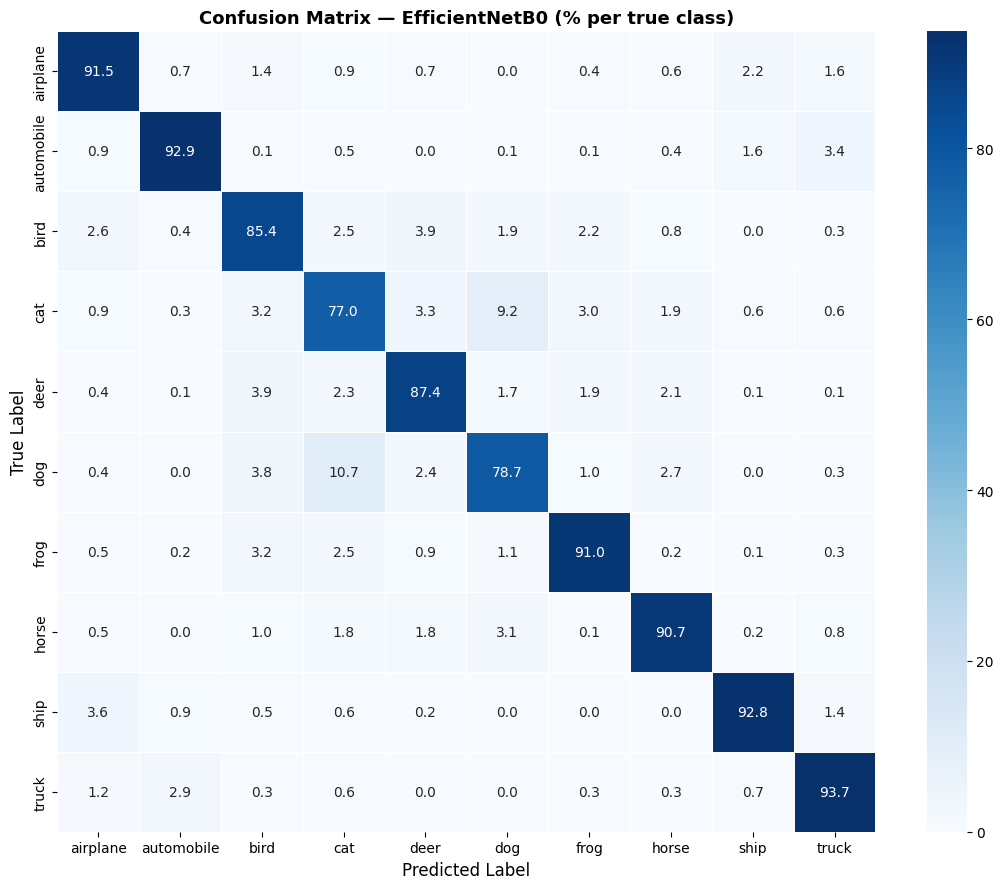

✅ Saved confusion matrix

📊 Per-Class Classification Report:
              precision    recall  f1-score   support

    airplane       0.89      0.92      0.90      1000
  automobile       0.94      0.93      0.94      1000
        bird       0.83      0.85      0.84      1000
         cat       0.77      0.77      0.77      1000
        deer       0.87      0.87      0.87      1000
         dog       0.82      0.79      0.80      1000
        frog       0.91      0.91      0.91      1000
       horse       0.91      0.91      0.91      1000
        ship       0.94      0.93      0.94      1000
       truck       0.91      0.94      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
# CELL 8: Confusion Matrix for Best Model
# Shows WHICH classes are confused — great paper insight!
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
# Find best model name
best_model_name = max(all_results, key=lambda k: all_results[k]["best_test_acc"])
print(f"🏆 Best Model: {best_model_name} — loading best weights...")
# Reload best model
model_loaders = {
    "ResNet18"      : get_resnet18,
    "VGG16"         : get_vgg16,
    "MobileNetV2"   : get_mobilenetv2,
    "EfficientNetB0": get_efficientnet_b0,
}

best_model = model_loaders[best_model_name]().to(device)
best_model.load_state_dict(torch.load(f'{best_model_name}_best.pth'))
best_model.eval()
# Collect predictions
all_preds, all_targets = [], []
with torch.no_grad():
    for inputs, labels in testloader:
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.numpy())
# Plot confusion matrix
cm = confusion_matrix(all_targets, all_preds)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax)
ax.set_title(f"Confusion Matrix — {best_model_name} (% per true class)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.savefig(f"figure8_confusion_matrix_{best_model_name}.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved confusion matrix")
# Per-class report (goes in your paper's appendix!)
print("\n📊 Per-Class Classification Report:")
print(classification_report(all_targets, all_preds, target_names=classes))

In [ ]:
# ============================================================
# CELL 9: Final Research Summary
# ============================================================

print("\n" + "="*75)
print("  FINAL BENCHMARK RESULTS — CIFAR-10 CLASSIFICATION")
print("="*75)
print(f"  {'Model':<22} {'Test Acc':>10} {'Params':>10} {'Time':>10}  Notes")
print("-"*75)

for name, res in all_models.items():
    notes = ""
    if res["best_test_acc"] == max(r["best_test_acc"] for r in all_models.values()):
        notes = "← Best Accuracy"
    if res["total_params_M"] == min(r["total_params_M"] for r in all_models.values()):
        notes = "← Most Efficient"
    print(f"  {res['model_name']:<22} "
          f"{res['best_test_acc']:>9.2f}% "
          f"{res['total_params_M']:>9.2f}M "
          f"{res['total_time_min']:>8.1f}m  {notes}")

print("="*75)


  FINAL BENCHMARK RESULTS — CIFAR-10 CLASSIFICATION
  Model                    Test Acc     Params       Time  Notes
---------------------------------------------------------------------------
  SimpleCNN (Baseline)       80.87%      1.15M      5.0m  ← Most Efficient
  ResNet18                   87.33%     11.18M     12.6m  
  VGG16                      31.06%    134.30M     22.7m  
  MobileNetV2                87.63%      2.24M     15.2m  
  EfficientNetB0             88.11%      4.02M     17.8m  ← Best Accuracy
